# <p align = "center"> Conformation Analysis </p>
## <p align = "center"> rmsd | rmsf | angles </p>


In [1]:
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator

import gemmi 
import parasail
import numpy as np
from rdkit import Chem

from xaidar.data.molecModels import get_pdb_stats, sele_pdb, sele_Lig, get_res_CoM
from xaidar.data.molecModels import flatten_pdb, sele_AA, createPDB, get_atom_coord

- ## Load Proteins and Fragments of Interest

In [2]:
# Load Fragalysis data (nonactivepdbs_dir, fragscreen_dir, piperid_dir, ...)
from xaidar.data.protocols import load_and_filter_Proteins, extract_lig_from_prot
# 1. Loading Fragalyis data Root Directory
rootProjDir = rootdir / "data/ev2a/fragalysis"
fragalysisDir =  rootdir / "data/ev2a/fragalysis"

# 2. Load Fragalysis Protein Directories
nonactivepdbs_dir = fragalysisDir / "02-chemofint/nonactivesite"
fragscreen_dir = fragalysisDir / "02-chemofint/fragscreen"
piperid_dir = fragalysisDir / "02-chemofint/piperid"

# 3. Load Fragments
nonactive_ligs = extract_lig_from_prot( nonactivepdbs_dir )
fragscreen_ligs = extract_lig_from_prot( fragscreen_dir )
piperid_ligs = extract_lig_from_prot( piperid_dir )
all_ligs = nonactive_ligs + fragscreen_ligs + piperid_ligs

# print( "Extracted {} ligands from nonactivepdbs_dir".format(
#     sum( [ 1 for lig in nonactive_ligs if lig is not None ] ) ) )
# print( "Extracted {} ligands from fragscreen_dir".format(
#     sum( [ 1 for lig in fragscreen_ligs if lig is not None ] ) ) )
# print( "Extracted {} ligands from piperid_dir".format(
#     sum( [ 1 for lig in piperid_ligs if lig is not None ] ) ) )


# 4. Compute Mean CoM for each set of proteins for filtering
lst_ligs = [ flatten_pdb( lig_pdb, "residue")[0] for lig_pdb in all_ligs if lig_pdb is not None ]
CoM_array = get_res_CoM(  lst_ligs  )
mean_CoM = CoM_array.mean(axis=0)
mean_CoM = gemmi.Position( *mean_CoM )
# print( "Ligands CoM array shape: ", CoM_array.shape)
# print( "Mean CoM from all ligands: ",mean_CoM )

# 5. Load Fragalysis Protein Files
nonactive_prots, nonactive_logs = load_and_filter_Proteins( nonactivepdbs_dir, 
                                                                    mean_CoM )
fragscreen_prots, fragscreen_logs = load_and_filter_Proteins( fragscreen_dir, 
                                                                    mean_CoM )
piperid_prots, piperid_logs = load_and_filter_Proteins( piperid_dir, 
                                                                    mean_CoM )

# print( "Loaded {} proteins after filtering from nonactive".format( len(nonactive_prots) ) )
# print( "Loaded {} proteins after filtering from fragscreen".format( len(fragscreen_prots) ) )
# print( "Loaded {} proteins after filtering from piperid".format( len(piperid_prots) ) )  

- ## Check the variation in the proteins CoM

In [3]:
# Compute Center of Mass for each protein set -> all_CoM_dict: {"nonactive":.., "fragscreen":.., "piperid":.., "all":..}
all_CoM_dict = {}
for prot_list, name in zip( [nonactive_prots, fragscreen_prots, piperid_prots], 
                            ["nonactive", "fragscreen", "piperid"] ):
    # print( "Processing CoM for {} proteins".format(name) )
    CoM_lst = []
    for prot in prot_list:
        chain = flatten_pdb( prot, "chain" )[0]
        chain_CoM = chain.calculate_center_of_mass()
        chain_CoM = [ chain_CoM.x, chain_CoM.y, chain_CoM.z ]
        CoM_lst.append( chain_CoM )
    all_CoM_dict[name] = np.array( CoM_lst  )

all_CoM = np.array( [np.array(item)  for lst in all_CoM_dict.values() for item in lst]   )
all_CoM_dict["all"] = all_CoM

# for name, CoM_array in all_CoM_dict.items():
#     print( "{} CoM array shape: {}".format( name, CoM_array.shape ) )

In [4]:
# Calculate overall CoM and Variation -> all_CoM_data: { "name": {"data":..., "mean":..., "dist":...} }
all_CoM_data = {}

for name in  ["nonactive", "fragscreen", "piperid", "all"]:
    CoM_stats = {}
    CoM_data = all_CoM_dict[name]
    CoM_mean = np.mean( CoM_data, axis=0 )
    CoM_dist = np.linalg.norm( CoM_data - CoM_mean, axis=1 )
    CoM_stats["data"], CoM_stats["mean"], CoM_stats["dist"] = CoM_data, CoM_mean, CoM_dist
    all_CoM_data[name] = CoM_stats

# for name in ["nonactive", "fragscreen", "piperid", "all"]:
#     print("Prot Library: {}".format(name))
#     print("\tData: {}".format( all_CoM_data[name]["data"].shape))
#     print("\tMean: {}".format( all_CoM_data[name]["mean"].shape))
#     print("\tDist: {}".format( all_CoM_data[name]["dist"].shape))


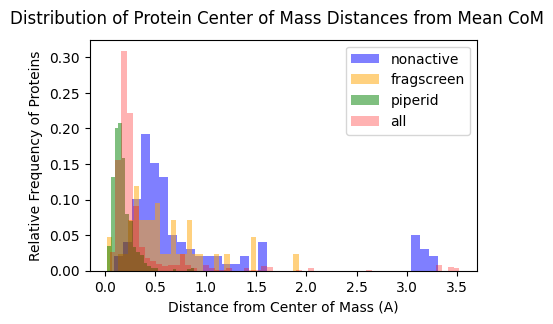

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots( 1,1, figsize = (5, 3), sharey=True, sharex = True )

for name, bin, color, alpha in  zip(["nonactive", "fragscreen", "piperid", "all"],
                         [0.6, 0.6, 0.4, 1],
                          ["blue", "orange", "green", "red"],
                           [0.5, 0.5, 0.5, 0.3] ): # [ 0,0,0,1] ): # 
    bin = int(60 * bin)
    CoM_dist = all_CoM_data[name]["dist"]
    ax.hist( CoM_dist, bins= bin, weights = np.ones_like(CoM_dist) / len(CoM_dist) ,label = name, alpha=alpha, color=color )
ax.set_ylabel( "Relative Frequency of Proteins")
ax.set_xlabel( "Distance from Center of Mass (A)")
ax.legend()
plt.suptitle( "Distribution of Protein Center of Mass Distances from Mean CoM" )
plt.show()

- ## Align All Proteins

1. Global Align
2. Refined Local Align

In [6]:
# Select Reference Protein based on Minimum Distance from Mean CoM -> ref_prot
ref_prot_dict = {}
for name, prot_list in zip( ["nonactive", "fragscreen", "piperid"],
                            [nonactive_prots, fragscreen_prots, piperid_prots] ):
    CoM_dist = all_CoM_data[name]["dist"]
    min_idx = np.argmin( CoM_dist )
    min_CoM =  all_CoM_data[name]["dist"][ min_idx ]
    ref_prot = prot_list[ min_idx ]
    ref_prot_dict[name] = ref_prot
    print( "Reference Protein for {} selected: {}".format( name, (ref_prot.name, round(min_CoM,3) ) )    )

print( "Chosen Reference Protein: fragscreen - A0926a" )
ref_prot = ref_prot_dict["fragscreen"]

Reference Protein for nonactive selected: ('A0354a', np.float64(0.085))
Reference Protein for fragscreen selected: ('A0926a', np.float64(0.02))
Reference Protein for piperid selected: ('A3207a', np.float64(0.022))
Chosen Reference Protein: fragscreen - A0926a


In [7]:
# Get Test Protein with Largest Com Distance from CoM Mean -> test_prot
test_prot_dict = {}
for name, prot_list in zip( ["nonactive", "fragscreen", "piperid"],
                            [nonactive_prots, fragscreen_prots, piperid_prots] ):
    CoM_dist = all_CoM_data[name]["dist"]
    max_idx = np.argmax( CoM_dist )
    max_CoM =  all_CoM_data[name]["dist"][ max_idx ]
    test_prot = prot_list[ max_idx ]
    test_prot_dict[name] = test_prot
    print( "Test Protein for {} selected: {}".format( name, (test_prot.name, round(max_CoM,3) ) )    )

print( "Chosen Test Protein: nonactive - A7501a" )
test_prot = test_prot_dict["nonactive"]


Test Protein for nonactive selected: ('A7501a', np.float64(3.309))
Test Protein for fragscreen selected: ('A0526a', np.float64(1.925))
Test Protein for piperid selected: ('A3222a', np.float64(0.888))
Chosen Test Protein: nonactive - A7501a


### Figuring out alignment

In [83]:
print(np.mean(np.array([(atom.pos.x,atom.pos.y,atom.pos.z) for atom in  flatten_pdb( test_prot, "residue")[0]]), axis=0)     )

[22.10666667 13.30366667 25.0265    ]


In [ ]:
def align_proteins( ref_prot: gemmi.Structure, mobile_prot: gemmi.Structure ) -> gemmi.Transform:
    supresult = gemmi.calculate_superposition( flatten_pdb(ref_prot, "chain")[0].whole(),
                                             flatten_pdb(mobile_prot, "chain" )[0].whole(),
                                              flatten_pdb(ref_prot, "chain")[0].whole().check_polymer_type(),
                                              gemmi.SupSelect.All, )
    flatten_pdb(mobile_prot, "chain" )[0].whole().transform_pos_and_adp(supresult.transform)
    return supresult.transform

In [ ]:
# 
test_prot_align =test_prot.clone()
supresult_before = gemmi.calculate_current_rmsd( flatten_pdb(ref_prot, "chain")[0].whole(), 
                             flatten_pdb(test_prot_align, "chain" )[0].whole(),
                              ptype = flatten_pdb(ref_prot, "chain")[0].whole().check_polymer_type(),
                              sel = gemmi.SupSelect.All) # All, MainChain, CaP (only Cα atoms (for peptides) and P atoms (for nucleotides) )
rot_matrix = supresult_before.transform.mat # Rotation Matrix
trans_vect = supresult_before.transform.vec # Translation Vector
print("Rmsd: ", supresult_before.rmsd)
print("Rotation Matrix:\n", rot_matrix)
print("Translation Vector:\n", trans_vect)

print()

supresult_after = gemmi.calculate_superposition( flatten_pdb(ref_prot, "chain")[0].whole(),
                                             flatten_pdb(test_prot_align, "chain" )[0].whole(),
                                             flatten_pdb(ref_prot, "chain")[0].whole().check_polymer_type(),
                                             gemmi.SupSelect.All, )
                                            # trim_cutoff= 2.0)
rot_matrix = supresult_after.transform.mat # Rotation Matrix
trans_vect = supresult_after.transform.vec # Translation Vector
print("Rmsd: ", supresult_after.rmsd)
print("Rotation Matrix:\n", rot_matrix)
print("Translation Vector:\n", trans_vect)

print()

print( "Ref Prot Atom Pos: ", ref_prot[0]["B"][0][0].pos )
print( "Test Prot Atom Pos: ", test_prot[0]["A"][0][0].pos )
print( "Aligned Test Prot Atom Pos: ", test_prot_align[0]["A"][0][0].pos )
test_prot_align[0]["A"].whole().transform_pos_and_adp(supresult_after.transform)
print( "Aligned Test Prot Atom Pos: ", test_prot_align[0]["A"][0][0].pos )

Rmsd:  10.5925665200077
Rotation Matrix:
 <gemmi.Mat33 [1, 0, 0]
             [0, 1, 0]
             [0, 0, 1]>
Translation Vector:
 <gemmi.Vec3(0, 0, 0)>

Rmsd:  0.75135131336274
Rotation Matrix:
 <gemmi.Mat33 [0.670284, 0.596009, -0.442146]
             [-0.721815, 0.661976, -0.201918]
             [0.172345, 0.45449, 0.87392]>
Translation Vector:
 <gemmi.Vec3(7.0267, 17.6825, -6.98399)>

Ref Prot Atom Pos:  <gemmi.Position(17.43, 6.362, 25.238)>
Test Prot Atom Pos:  <gemmi.Position(20.808, 13.206, 25.917)>
Aligned Test Prot Atom Pos:  <gemmi.Position(20.808, 13.206, 25.917)>
Aligned Test Prot Atom Pos:  <gemmi.Position(17.3858, 6.17196, 25.2535)>


### Figuring out calculating rmsd

- How to account for occupancies less than 1

In [86]:
print( flatten_pdb(ref_prot, "residue"))
chain = gemmi.Chain("a")
chain.append_residues( flatten_pdb(ref_prot, "residue") )
print(chain.whole() )

[<gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 8(GLY) with 4 atoms>, <gemmi.Residue 9(ALA) with 5 atoms>, <gemmi.Residue 10(ILE) with 8 atoms>, <gemmi.Residue 11(TYR) with 12 atoms>, <gemmi.Residue 12(VAL) with 7 atoms>, <gemmi.Residue 13(GLY) with 4 atoms>, <gemmi.Residue 14(ASN) with 8 atoms>, <gemmi.Residue 15(TYR) with 12 atoms>, <gemmi.Residue 16(ARG) with 11 atoms>, <gemmi.Residue 17(VAL) with 7 atoms>, <gemmi.Residue 18(VAL) with 7 atoms>, <gemmi.Residue 19(ASN) with 8 atoms>, <gemmi.Residue 20(ARG) with 11 atoms>, <gemmi.Residue 21(HIS) with 10 atoms>, <gemmi.Residue 22(LEU) with 8 atoms>, <gemmi.Residue 23(ALA) with 5 atoms>, <gemmi.Residue 24(THR) with 7 atoms>, <gemmi.Residue 25(HIS) with 10 atoms>, <gemmi.Residue 26(ASN) with 8 atoms>, <gemmi.Residue 27(ASP) with 8 atoms>, <gemmi.Residue 28(TRP) with 14 atoms>, <gemmi.Residue 29(ALA) with 5 atoms>, <gemmi.Residue 30(ASN) with 8 atoms>, <gemmi.Residue 31(LEU) with 8 atoms>, <gemmi.Residue 32(VAL) with 7 atoms>, <gemmi.

In [87]:
test_prot[0]["A"].whole().transform_pos_and_adp

In [88]:
print(np.mean(np.array([(atom.pos.x,atom.pos.y,atom.pos.z) for atom in  flatten_pdb( test_prot, "residue")[0]]), axis=0)     )
flatten_pdb( test_prot, "chain")[0].whole().transform_pos_and_adp( supresult_after.transform )
print(np.mean(np.array([(atom.pos.x,atom.pos.y,atom.pos.z) for atom in  flatten_pdb( test_prot, "residue")[0]]), axis=0)     )


[22.10666667 13.30366667 25.0265    ]
[18.70819583  5.47902475 24.74352128]


In [132]:
# rmse for a residue
from xaidar.data.molecModels import  model_seqAlign
align = model_seqAlign( ref_prot, test_prot).map_matching_res( )
ref_res = align.matched_res["Ref"]
test_res = align.matched_res["Query"]
print( "Number of Matched Residues: ", len(ref_res) )
print( "Number of Matched Residues: ", len(test_res) )

ref_num_atoms = [ len(res) for res in ref_res ]
test_num_atoms = [ len(res) for res in test_res ]
for i, (r_na, t_na) in enumerate( zip(ref_res, test_res) ):
    if len(r_na) != len(t_na):
        print( "Residue Index: {}, Ref Num Atoms: {}, Test Num Atoms: {}".format(i, len(r_na), len(t_na)) )


val_ref_res = ref_res[11]
print( val_ref_res.name, len( val_ref_res) )
val_ref_res_names = [ atom.name for atom in val_ref_res ]
val_test_res = test_res[11]
print( "Reference Residue Atoms: ", val_ref_res_names)
print( "Test Residue Atoms: ", [ atom.name for atom in val_test_res ] )

print( "Number of Atoms in Reference Residue: ", len([ atom.pos for atom in val_ref_res]) )
print( "Number of Atoms in Test Residue: ",len( [atom.pos for atom in val_test_res
                                    if atom.name in val_ref_res_names]) )

val_test_atom = [ atom for atom in val_test_res if atom.name == "CG2"]

print( val_test_atom[1].occ )
# rmsd = gemmi.superpose_positions( [ atom.pos for atom in val_ref_res], 
#                                     [atom.pos for atom in val_test_res
#                                     if atom.name in val_ref_res_names] ).rmsd

# print( rmsd)

# ref_res = flatten_pdb( ref_prot, "chain")[0].whole()[0]
# test_res = flatten_pdb( test_prot, "chain")[0].whole()[0]

# ref_at_pos_lst = [ atom.pos for atom in ref_res]
# test_at_pos_lst = [atom.pos for atom in test_res]
# print( ref_at_pos_lst,"\n", test_at_pos_lst)
# gemmi.superpose_positions( ref_at_pos_lst, test_at_pos_lst).rmsd


def get_res_rmsd( res_lst_1, res_lst_2):
    res_rmsd_lst = []
    
    for res_1, res_2 in zip( res_lst_1, res_lst_2):
        ref_res = [  res_1, res_2][ int(np.argmin([ len(res_1), len(res_2)]) ) ]
        ref_atom_lst = [ atom.name for atom in ref_res ]
        query_res = [  res_1, res_2][ int(np.argmax([ len(res_1), len(res_2)]) ) ]

        res_rmsd_lst.append( gemmi.superpose_positions( [ atom.pos for atom in ref_res], 
                                    [atom.pos for atom in query_res
                                    if atom.name in ref_atom_lst] ).rmsd)
                     
    return res_rmsd_lst



Number of Matched Residues:  135
Number of Matched Residues:  135
Residue Index: 11, Ref Num Atoms: 7, Test Num Atoms: 11
Residue Index: 29, Ref Num Atoms: 12, Test Num Atoms: 9
Residue Index: 58, Ref Num Atoms: 6, Test Num Atoms: 9
Residue Index: 66, Ref Num Atoms: 12, Test Num Atoms: 9
Residue Index: 75, Ref Num Atoms: 9, Test Num Atoms: 15
VAL 7
Reference Residue Atoms:  ['N', 'CA', 'C', 'O', 'CB', 'CG1', 'CG2']
Test Residue Atoms:  ['N', 'CA', 'CB', 'CG1', 'CG2', 'C', 'O', 'CA', 'CB', 'CG1', 'CG2']
Number of Atoms in Reference Residue:  7
Number of Atoms in Test Residue:  11
0.5


In [113]:
int(np.argmin([5,0,1]))

1

In [114]:
print( len(ref_res[5]))
print( [ atom.name for atom in ref_res[5] ])

TypeError: object of type 'Atom' has no len()

In [117]:
ref_res = flatten_pdb( ref_prot, "residue")
query_res = flatten_pdb( test_prot, "residue")
rmsd_lst = get_res_rmsd(ref_res, query_res)
print(rmsd_lst)

RuntimeError: superpose_positions: pos1 and pos2 must have equal lengths